In [1]:
# Leave the RIKS1 and RISK3 with negative values.
# Take abs(y_train) coz 'CM' and 'CHARGE' have to be positive.


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
# Charger les données
print("Chargement des données...")
X_train = pd.read_csv("train_input_Z61KlZo.csv")
y_train = pd.read_csv("train_output_DzPxaPY.csv")
X_test = pd.read_csv("test_input_5qJzHrr.csv")
print("Données chargées avec succès.")
# Attention: des colonnes comme 'FRCH1' contiennent des str et float à la fois, d'où les messages en bas. 

Chargement des données...


/tmp/ipykernel_5962/2007440270.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("train_input_Z61KlZo.csv")
/tmp/ipykernel_5962/2007440270.py:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("test_input_5qJzHrr.csv")


Données chargées avec succès.


### y_train

In [10]:
y_train.columns

Index(['ID', 'FREQ', 'CM', 'ANNEE_ASSURANCE', 'CHARGE'], dtype='object')

In [19]:
len(y_train[y_train['CHARGE']!=0])/len(y_train)

0.00614686791272386

0.614% de 'CHARGE' sont non nulles. Il serait alors préférable de commencer par un algo de classification ensuite prédiction de la valeur exacte de 'CHARGE'.

In [28]:
# Certaines valeurs sont négative dans y_train.
y_train=y_train.abs()

### Dropping features with few info

In [32]:
#The proportions of null are equal between train and test. Get rid of some columns to make life simpler

# Calculate percentage of nulls per column
null_train = (X_train.isnull().sum() / len(X_train)) * 100
null_test = (X_test.isnull().sum() / len(X_test)) * 100

# Convert to DataFrame for better display
null = pd.DataFrame({'column': null_train.index, 'null_train': null_train.values,'null_test': null_test.values })
col_drop=null[null['null_test']>55]['column'].to_list()

#drop the columns
X_train = X_train.drop(columns=col_drop, axis=1)
X_test = X_test.drop(columns=col_drop, axis=1)


In [41]:
print('The dropped features are:', col_drop)
print('Number of features dropped:', len(col_drop))
print('Number of features is now:', len(X_train.columns)-1)

The dropped features are: ['CARACT2', 'CARACT3', 'TYPBAT1', 'DEROG12', 'DEROG13', 'DEROG14', 'DEROG16', 'DISTANCE_111', 'DISTANCE_112', 'DISTANCE_121', 'DISTANCE_122', 'DISTANCE_123', 'DISTANCE_124', 'DISTANCE_131', 'DISTANCE_132', 'DISTANCE_133', 'DISTANCE_141', 'DISTANCE_142', 'DISTANCE_211', 'DISTANCE_212', 'DISTANCE_213', 'DISTANCE_221', 'DISTANCE_222', 'DISTANCE_223', 'DISTANCE_231', 'DISTANCE_242', 'DISTANCE_243', 'DISTANCE_244', 'DISTANCE_311', 'DISTANCE_312', 'DISTANCE_313', 'DISTANCE_321', 'DISTANCE_322', 'DISTANCE_323', 'DISTANCE_324', 'DISTANCE_331', 'DISTANCE_332', 'DISTANCE_333', 'DISTANCE_334', 'DISTANCE_335', 'DISTANCE_411', 'DISTANCE_412', 'DISTANCE_421', 'DISTANCE_422', 'DISTANCE_423', 'DISTANCE_511', 'DISTANCE_512', 'DISTANCE_521', 'DISTANCE_522', 'DISTANCE_523', 'DISTANCE_1', 'DISTANCE_2', 'ALTITUDE_1', 'BDTOPO_BAT_MAX_HAUTEUR_MAX', 'HAUTEUR', 'HAUTEUR_MAX', 'BDTOPO_BAT_MAX_HAUTEUR', 'NBJTX25_MM_A', 'NBJTX25_MMAX_A', 'NBJTX25_MSOM_A', 'NBJTX0_MM_A', 'NBJTX0_MMAX_A', 

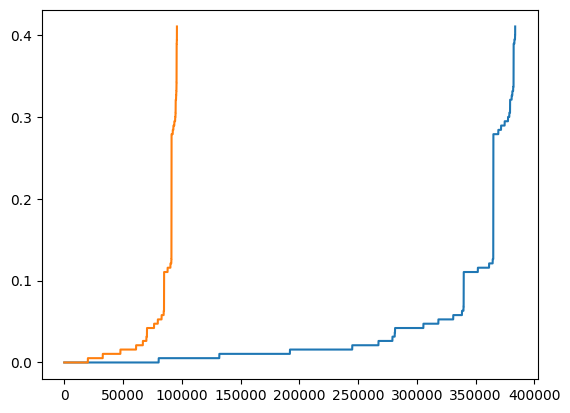

In [55]:
# Few Nan's left, their distribution is similar between Trai and Test
nan_counts = X_train.isna().sum(axis=1)/190
nan_counts_test = X_test.isna().sum(axis=1)/190
plt.plot(sorted(nan_counts.tolist()))
plt.plot(sorted(nan_counts_test.tolist()))

In [ ]:
### Enc

### All data